In [1]:
import jupyter_black

jupyter_black.load()

In [2]:
# Importing Libraries

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import astroalign as aa
import gc

from astropy.coordinates import SkyCoord

/Users/alec/honours-env/.venv/lib/python3.11/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)


In [3]:
def quickimdisplay(image, vmin=5, vmax=95, title=""):
    if vmin == vmax:
        vmin = np.percentile(image, 5)
        vmax = np.percentile(image, 95)
    vmin = np.percentile(image, vmin)
    vmax = np.percentile(image, vmax)
    plt.imshow(image, origin="lower", vmin=vmin, vmax=vmax, cmap="inferno")
    plt.xlabel("x pixels")
    plt.ylabel("y pixels")
    plt.title(title)
    s = len(image) / len(image[0])
    if s > 1:
        s = 1
    plt.colorbar(shrink=s, label="Counts")
    plt.show()

In [ ]:
r_median = CCDData.read("r_median.fits")
b_median = CCDData.read("b_median.fits")
g_median = CCDData.read("g_median.fits")

xmin = 400
xmax = 1000
ymin = 400
ymax = 1200

r_median = r_median[ymin:ymax, xmin:xmax]
b_median = b_median[ymin:ymax, xmin:xmax]
g_median = g_median[ymin:ymax, xmin:xmax]

None


In [5]:
r_bkg = Background2D(r_median, 100)
b_bkg = Background2D(b_median, 100)
g_bkg = Background2D(g_median, 100)

r_processed = r_median.copy()
r_processed.data = r_median.data - r_bkg.background.value
r_processed.write("r_median.fits", overwrite=True)

b_processed = b_median.copy()
b_processed.data = b_median.data - b_bkg.background.value
b_processed.write("b_median.fits", overwrite=True)

g_processed = g_median.copy()
g_processed.data = g_median.data - g_bkg.background.value
g_processed.write("g_median.fits", overwrite=True)

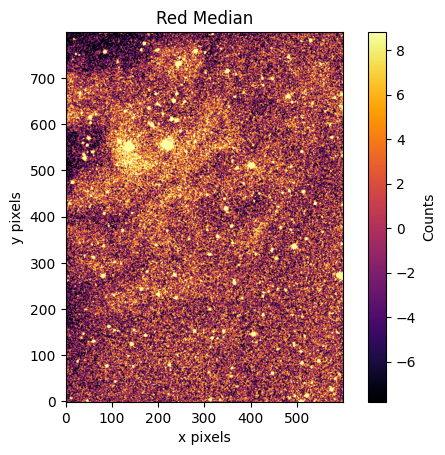

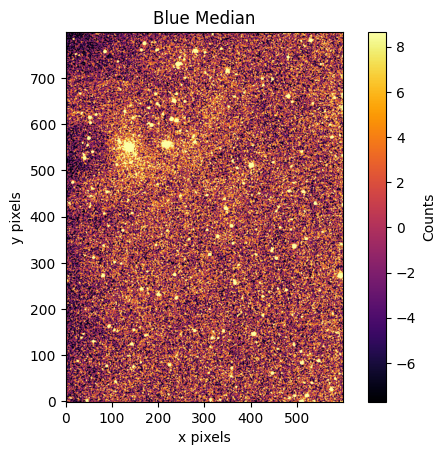

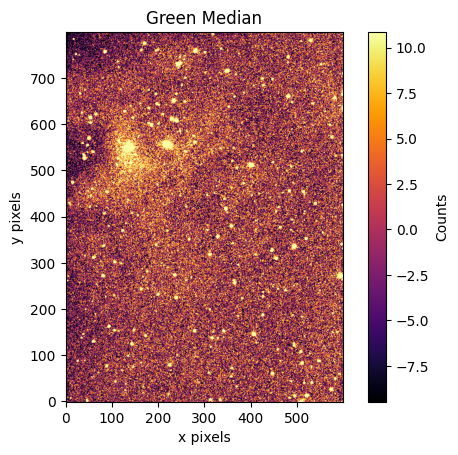

In [6]:
quickimdisplay(r_processed.data, title="Red Median")
quickimdisplay(b_processed.data, title="Blue Median")
quickimdisplay(g_processed.data, title="Green Median")